# Libraries

In [ ]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.container import BarContainer

# Configuration

In [21]:
# Kernel CWD is notebooks/ (the notebook's dir), not the project root,
# so resolve relative to the project root regardless of where the kernel started
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
METRICS_ROOT = PROJECT_ROOT / 'eval/xquad_xlmr/-1/'

# Visualization

In [22]:
# Dynamically get all metrics.csv files
csv_paths = sorted(Path(METRICS_ROOT).glob('**/metrics.csv'))
csv_paths = [str(p) for p in csv_paths] # make string paths
if not csv_paths:
    raise FileNotFoundError(f"No metrics.csv found under {METRICS_ROOT.resolve()}")
print(f"CSV paths: {csv_paths}")

CSV paths: ['/Users/alimtegar/Developer/LegameX/eval/xquad_xlmr/-1/alxxtexxr/XLM-R-Base-squad-en-15K-s42-LoRA-mrg-v260922221946/metrics.csv']


In [23]:
# Read the CSV files and concatenate them into a single DataFrame
df = pd.concat([pd.read_csv(p) for p in csv_paths], 
               keys=csv_paths, 
               names=['csv_path', None]).reset_index(level=0)

# Add a new column 'model' to the DataFrame by extracting the model name from the CSV path
df['model'] = df['csv_path'].apply(lambda p: os.path.basename(os.path.dirname(p)))

# Display the first few rows of the DataFrame to verify the data
df.head()

,csv_path,lang,test_exact_match,test_f1,test_model_preparation_time,test_runtime,test_samples_per_second,test_steps_per_second,model
0,/Users/alimtegar/Developer/LegameX/eval/xquad_...,en,65.714286,76.945039,0.005,21.1349,58.340,3.691,XLM-R-Base-squad-en-15K-s42-LoRA-mrg-v26092222...
1,/Users/alimtegar/Developer/LegameX/eval/xquad_...,ar,45.126050,60.608367,0.005,25.1848,50.665,3.177,XLM-R-Base-squad-en-15K-s42-LoRA-mrg-v26092222...
2,/Users/alimtegar/Developer/LegameX/eval/xquad_...,de,51.008403,66.561133,0.005,26.4934,47.219,2.982,XLM-R-Base-squad-en-15K-s42-LoRA-mrg-v26092222...
3,/Users/alimtegar/Developer/LegameX/eval/xquad_...,el,49.327731,66.873677,0.005,32.0955,42.841,2.679,XLM-R-Base-squad-en-15K-s42-LoRA-mrg-v26092222...
4,/Users/alimtegar/Developer/LegameX/eval/xquad_...,es,51.428571,68.723193,0.005,25.2365,49.888,3.130,XLM-R-Base-squad-en-15K-s42-LoRA-mrg-v26092222...


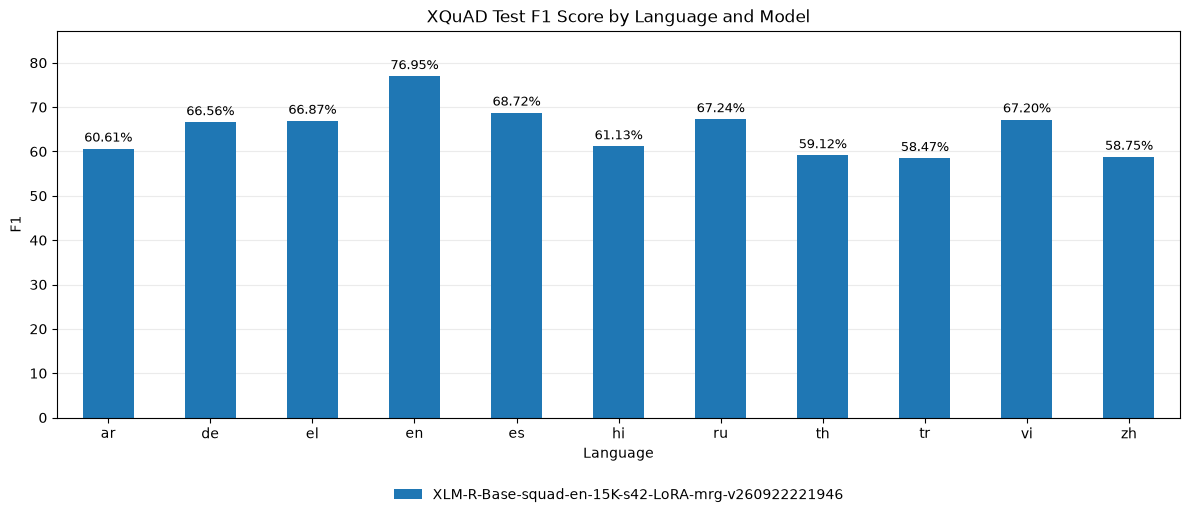

In [ ]:
# Plot with pandas pivot table
pivot = df.pivot(index='lang', columns='model', values='test_f1')
ax = pivot.plot(kind='bar', figsize=(12, 6), rot=0)
plt.title('XQuAD Test F1 Score by Language and Model')
plt.ylabel('F1')
plt.xlabel('Language')

# Add horizontal gridlines for each y-tick
ax.grid(axis='y', linestyle='-', alpha=0.25)
ax.set_axisbelow(True)  # Puts the lines behind the bars

# Add F1 score labels on top of each bar
for container in ax.containers:
    if isinstance(container, BarContainer):
        ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=9)

# Add some padding at the top so the highest label doesn't hit the border
y_max = ax.get_ylim()[1]
ax.set_ylim(0, y_max * 1.08)

# Move the legend below the plot, centered
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),    # (x, y) in axes coordinates; negative y pushes it below
    ncol=2,                         # two columns if you want to save horizontal space
    frameon=False,                  # optional: cleaner look without border
)

# Adjust the layout to make room for the legend
plt.tight_layout(rect=(0, 0.1, 1, 1))   # leave 10% of figure height at the bottom
plt.show()